<h2> Nauczanie maszynowe/Ćwiczenia1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('chipseq_expression_K562.txt')
df.head()

,gene_id,expression,H3K27ac_signal,H3K4me3_signal
0,1,5.050,5.745,4.190
1,2,5.746,4.793,4.827
2,3,5.868,5.972,4.049
3,4,7.412,7.285,4.630
4,5,2.942,4.649,2.728


In [3]:
d2 = df[["H3K27ac_signal","H3K4me3_signal"]]
target = df['expression']

Zastosujemy funkcję kosztu $MSE$.

<center>
$MSE(w) = \frac{1}{N}\sum_{i}(y^{pred}_{i}-t_i)^2$
    


W przypadku regresji liniowej 2 zmiennych:
    
<center>
$MSE(w_1,w_2,w_0) = \frac{1}{N}\sum_{i}(w_1x_{1,i}+w_2x_{2,i}+w_0-t_i)^2$

In [8]:
def loss_function(w1, w2, w0, X, t):
    """
    tutaj zdefiniuj funkcję, która przyjmuje jako argument wagi
    (w1,w2,w0), dane w postaci listy list (X) oraz wartosci (t),
    a ktora zwraca wartosc funkcji kosztu.
    """
    MSE = 0
    for i in range(X.shape[0]):
        MSE += ((w1 * X.iloc[i, 0]) + (w2 * X.iloc[i, 1]) + w0 - t.iloc[i])**2
    MSE = MSE/X.shape[0]
    return MSE

In [9]:
loss_function(3, 8, -1, d2, target)

2396.293371543177

In [80]:
#przykladowe wywolanie
loss_function(3, 8, -1, d2, target)

2396.2933715431755

In [10]:
loss_function(-0.5, 8, -23, d2, target)

146.4180874045962

In [81]:
#przykladowe wywolanie
loss_function(-0.5, 8, -23, d2, target) #lepiej

146.4180874045961

<h4> Zadanie1: Uzupełnij definicję powyższej funkcji.

Często na początku nie mamy informacji o tym jakie powinny być parametry modelu; możemy zacząć od losowych wartości. Pojawia się więc pytanie jak je aktualizować aby wartości funkcji kosztu były coraz mniejsze? Jedno z najpopularnieszych podejść (i stanowiące podstawę do innych algorytmów) jest opartę o metodę spadku gradientu (Gradient Descent). Liczymy pochodną funkcji kosztu po rozważanych parametrach a następnie aktualizujemu je wg:

<center>
$w_{new} = w_{old} - \eta \cdot \frac{d MSE}{dw}$
</center>

Ale:
    
* nie mamy gwarancji, że dojdziemy do minimum globalnego
* zły wybór długości kroku spowoduje katastrofalne rezultaty
* dla funkcji nieróżniczkowalnych w punktach (takich jak mean error czy maximum error) sytuacja staje się skomplikowana ...
* wiele, wiele innych.

In [15]:
def update_weights(w1, w2, w0, X, t, eta):
    """
    tutaj zdefiniuj funkcję, która przyjmuje jako argument wagi
    (w1,w2,w0), dane (X), wartosci (t) oraz wspolczynnik uczenia
    (eta), a ktora zwraca zaktualizowane wartosci w1, w2, w0
    """
    dMSE_w1 = 0
    dMSE_w2 = 0
    dMSE_w0 = 0
    
    for i in range(X.shape[0]):
        dMSE_w1 += ((w1 * X.iloc[i, 0]) + (w2 * X.iloc[i, 1]) + w0 - t.iloc[i]) * X.iloc[i, 0]
        dMSE_w2 += ((w1 * X.iloc[i, 0]) + (w2 * X.iloc[i, 1]) + w0 - t.iloc[i]) * X.iloc[i, 1]
        dMSE_w0 += ((w1 * X.iloc[i, 0]) + (w2 * X.iloc[i, 1]) + w0 - t.iloc[i])

    dMSE_w1 = 2/X.shape[0] * dMSE_w1
    dMSE_w2 = 2/X.shape[0] * dMSE_w2
    dMSE_w0 = 2/X.shape[0] * dMSE_w0

    w1_new = w1 - eta * dMSE_w1
    w2_new = w2 - eta * dMSE_w2
    w0_new = w0 - eta * dMSE_w0
    
    return(w1_new, w2_new, w0_new)

In [16]:
update_weights(3, 8, -1, d2, target, 0.001)

(2.507942804412256, 7.500080472785515, -1.0961084233983287)

In [83]:
#przykladowe wywolanie
update_weights(3, 8, -1, d2, target, 0.001)

(2.5079428044122563, 7.500080472785515, -1.0961084233983287)

<h4> Zadanie2: Uzupełnij definicję powyższej funkcji.

<h4> Zadanie3: Celem jest zbudowanie modelu regresji liniowej przewidującego $target$ w oparciu o $d2$. Wystartuj z początkowych parametrów 1, 1 oraz 1. Przyjmując $\eta=0.001$ wykonaj 100 aktualizacji tych parametrów na podstawie metody spadku gradientu. Narysuj zależność funkcji kosztu od numeru iteracji. Wykonaj analogiczne obliczenia dla $\eta=0.01$ oraz $\eta=0.00001$. Możesz potestować też inne zestawy parametrów początkowych (np. -100, 100, -100). Skomentuj otrzymane wyniki.

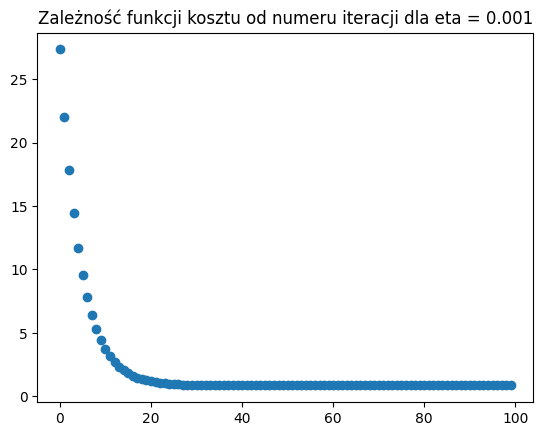

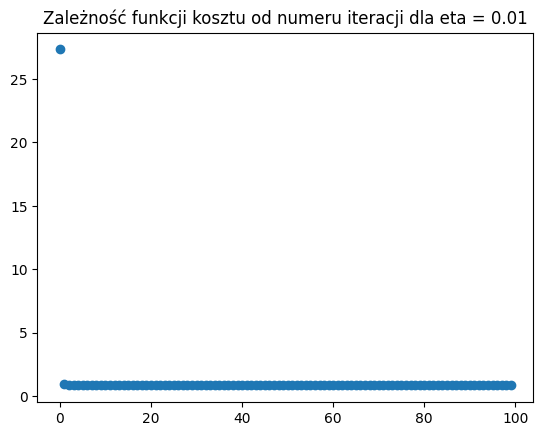

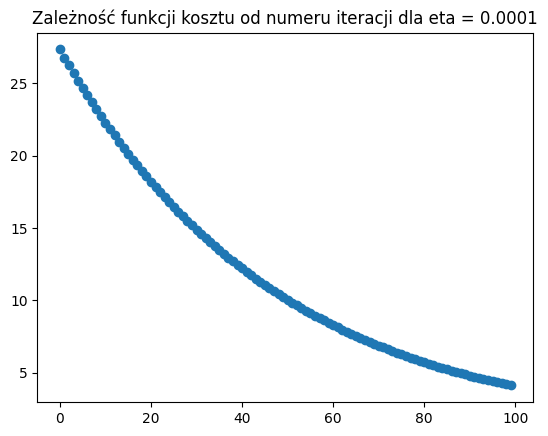

In [22]:
w1 = 1
w2 = 1
w0 = 1
eta = 0.001
MSE_001 = []

for i in range (100):
    MSE_001.append(loss_function(w1, w2, w0, d2, target))
    w1, w2, w0 = update_weights(w1, w2, w0, d2, target, eta)

plt.title("Zależność funkcji kosztu od numeru iteracji dla eta = 0.001")
plt.scatter(range(100), MSE_001)
plt.show()

w1 = 1
w2 = 1
w0 = 1
eta = 0.01
MSE_01 = []

for i in range (100):
    MSE_01.append(loss_function(w1, w2, w0, d2, target))
    w1, w2, w0 = update_weights(w1, w2, w0, d2, target, eta)

plt.title("Zależność funkcji kosztu od numeru iteracji dla eta = 0.01")
plt.scatter(range(100), MSE_01)
plt.show()

w1 = 1
w2 = 1
w0 = 1
eta = 0.0001
MSE_0001 = []

for i in range (100):
    MSE_0001.append(loss_function(w1, w2, w0, d2, target))
    w1, w2, w0 = update_weights(w1, w2, w0, d2, target, eta)

plt.title("Zależność funkcji kosztu od numeru iteracji dla eta = 0.0001")
plt.scatter(range(100), MSE_0001)
plt.show()

W przypadku eta równego 0.001 algorytm odnalazł minimum globalne około 25 iteracji - dalsze wykonywanie obliczeń było już w tym momencie bezsensowne, ponieważ wartość funkcji kosztu nie zmieniała się. Natomiast w przypadku większego eta - wpadliśmy w minimum globalne od razu po jednej iteracji, jednak tak wysoki "skok" jest potencjalnie bardzo niebiezpieczny - gdyby były inne wartości początkowe wag, prawdopodobnie nigdy byśmy do niego nie wpadli, a tylko "skakali" dookoła niego. Natomiast wartość eta 0.0001 była bardzo niska - bardzo powoli schodzilśmy do minimum, ale nigdy go nie osiągneliśmy. Potrzebna byłaby większa ilość iteracji, która tylko by się zwiększała z zwiększaniem wartości startowych parametrów. 

<h4> Zadanie4: Zazwyczaj nie wiemy z góry ile razy należy zmodyfikować wagi - kiedy dalsza aktualizacja nie przynosi efektu. Jednym z rozwiązań tego problemu jest sprawdzenie o jaki procent zmieniają sie aktualne wagi. Przyjmijmy, że jeżeli zmiana funkcji kosztu jest mniejsza niż 0,1% to przerywamy działanie. Ile kroków należałoby wykonać aby zrealizować poprzednie zadanie (dla wybranego zestawu pozostałych hiperparametrów)?

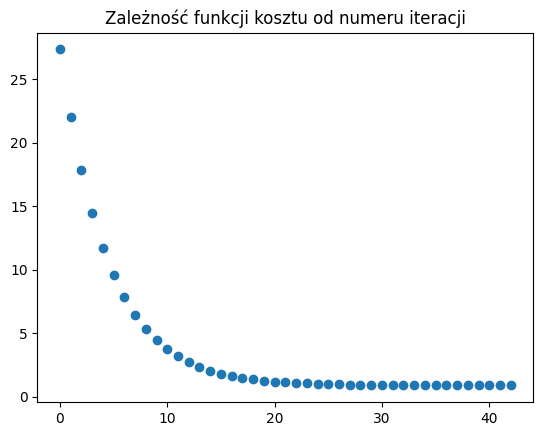

In [36]:
w1 = 1
w2 = 1
w0 = 1
eta = 0.001
MSE = []

for i in range (100):
    MSE.append(loss_function(w1, w2, w0, d2, target))
    if i > 0:
        change = abs(MSE[i] - MSE[i-1]) / MSE[i-1]
        if change < 0.001:
            break

    w1, w2, w0 = update_weights(w1, w2, w0, d2, target, eta)

plt.title("Zależność funkcji kosztu od numeru iteracji")
plt.scatter(range(len(MSE)), MSE)
plt.show()

Należałoby wykonać 42 kroki.

Oczywiście w Pythonie istnieje implementacja metody regresji liniowej

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model = LinearRegression()
model.fit(d2, target);

In [24]:
model.coef_ #wspolczynnki dla zmiennych

array([0.48164297, 0.74793775])

In [25]:
model.intercept_ #wyraz wolny

np.float64(-0.23377574137486512)

<h4> Zadanie5: Porównaj te parametry z otrzymanymi z Zadania3. Skomentuj otrzymane wyniki.

In [26]:
r_sq = model.score(d2, target) #R2 modelu
print(r_sq)

0.612546795100597


In [27]:
y_pred = model.predict(d2) #przewidywane y
print(y_pred[:5])

[5.66712228 5.68503452 5.67099601 6.73794505 4.04575659]


In [41]:
print("Przewidywane y według modelu z zadania 3")
for i in range(5):
    print((w1 * d2.iloc[i, 0]) + (w2 * d2.iloc[i, 1]) + w0)

Przewidywane y według modelu z zadania 3
5.9292918302887525
5.79703028236969
5.966560732676628
6.917204415934609
4.621510214228959


Model stworzony za pomocą sklearn pakieru ma dość niską wartość dopasowania (R^2) - poziom tego parametru jest na poziomie zaledwie 61%. Oznacza to, że parametry otrzymane za pomocą pakieru sklearn nie są najlepiej dopasowane i nie osiągnęły globalnego minimum. Można też zauważyć różnicę pomiędzy przewidywanymi wartościami y otrzymanymi tutaj i w zadaniu 3, gdzie algorytm doszedł do globalnego minimum. 

<h4> Zadanie6: Rozważ jeszcze raz dane $d2/target$.
    
- Podziel je na trzy podzbiory - treningowy (60%), walidacyjny (20%) oraz testowy (20%); najlepiej przez odpowiednią funkcję.
- Przetestuj różne wartości parametrów $\eta$ na zbiorze walidacyjnym, na tej podstawie wybierz jeden, który użyjesz do wytrenowania parametrów modelu na zbiórze treningowym.
- Na końcu wyznacz wartość funkcji kosztu na zbiorze testowym. Skomentuj otrzymane wyniki.

In [42]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_temp, y_train, y_temp = train_test_split(d2, target, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

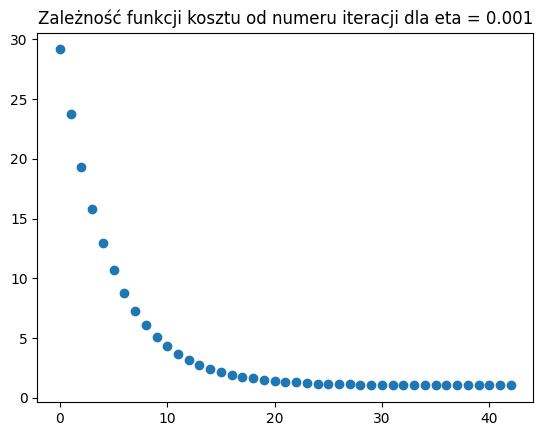

Funkcja kosztu: 1.0266038034321454


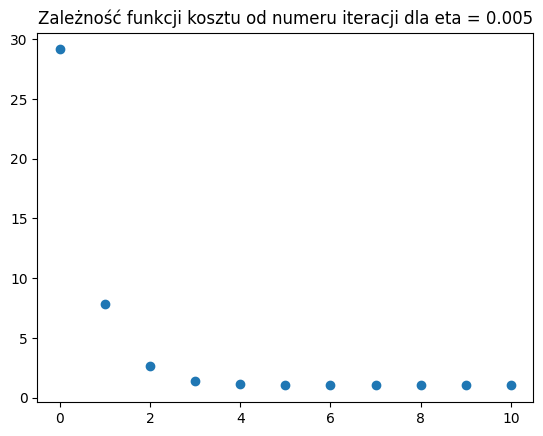

Funkcja kosztu: 1.0217438986497585


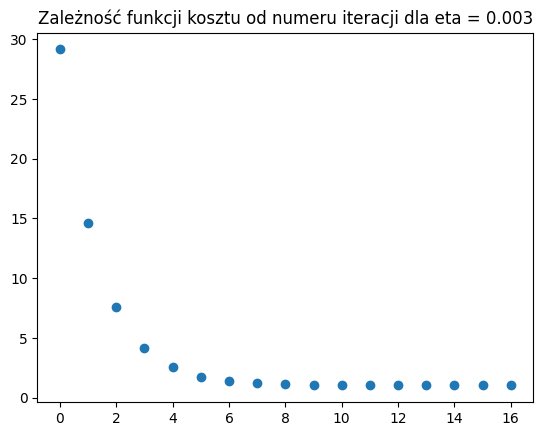

Funkcja kosztu: 1.022337232869091


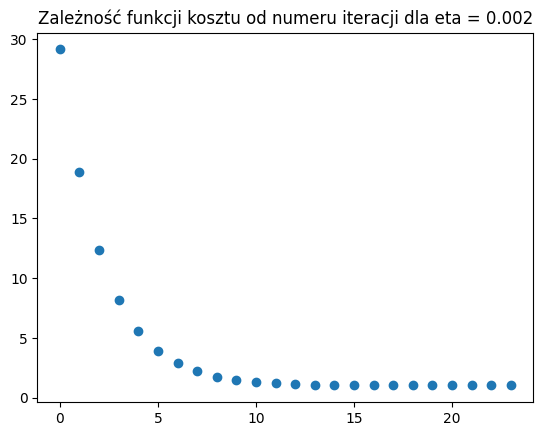

Funkcja kosztu: 1.023254577227605


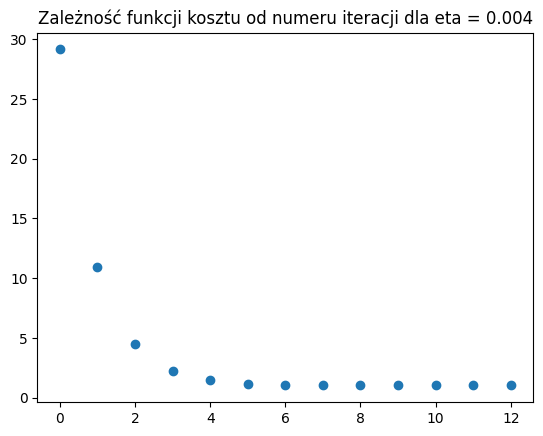

Funkcja kosztu: 1.0221801596021145


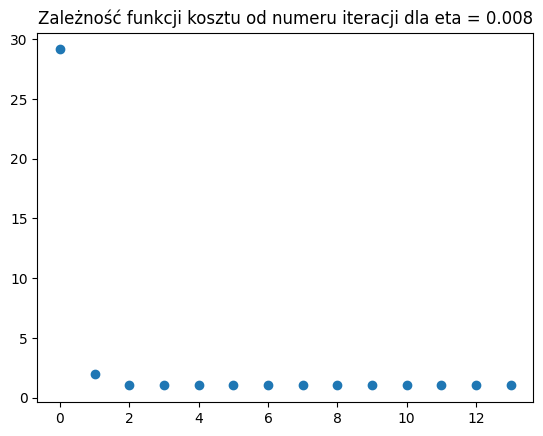

Funkcja kosztu: 1.0138402855619322


In [49]:
etas_to_test = [0.001, 0.005, 0.003, 0.002, 0.004, 0.008]

for eta in etas_to_test:
    MSE = []
    w1 = 1
    w2 = 1
    w0 = 1

    for i in range (100):
        MSE.append(loss_function(w1, w2, w0, X_val, y_val))
        if i > 0:
            change = abs(MSE[i] - MSE[i-1]) / MSE[i-1]
            if change < 0.001:
                break
    
        w1, w2, w0 = update_weights(w1, w2, w0, X_val, y_val, eta)
    
    plt.title(f"Zależność funkcji kosztu od numeru iteracji dla eta = {eta}")
    plt.scatter(range(len(MSE)), MSE)
    plt.show()
    print(f"Funkcja kosztu: {loss_function(w1, w2, w0, X_val, y_val)}")

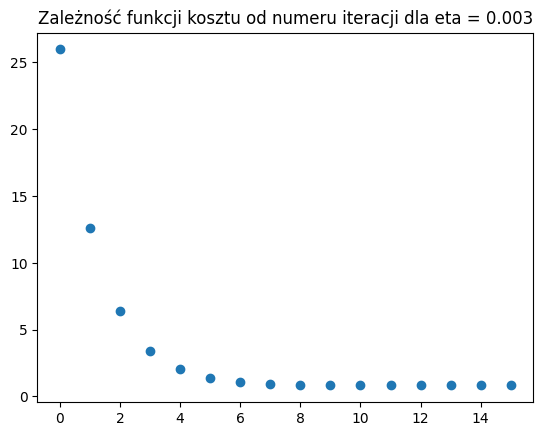

In [47]:
MSE = []
w1 = 1
w2 = 1
w0 = 1
eta = 0.003

for i in range (100):
    MSE.append(loss_function(w1, w2, w0, X_train, y_train))
    if i > 0:
        change = abs(MSE[i] - MSE[i-1]) / MSE[i-1]
        if change < 0.001:
            break
    
    w1, w2, w0 = update_weights(w1, w2, w0, X_train, y_train, eta)
    
plt.title(f"Zależność funkcji kosztu od numeru iteracji dla eta = {eta}")
plt.scatter(range(len(MSE)), MSE)
plt.show()

In [48]:
print(f"Funckja kosztu na zbiorze testowym wynosi {loss_function(w1, w2, w0, X_test, y_test)}")

Funckja kosztu na zbiorze testowym wynosi 0.820872922582769


Do trenowania wybrałam eta o wartości 0.003, ponieważ osiągał dość niską wartość funkcji kosztu na zbiorze walidacyjnym, a jednocześnie nie był wysoki, tak że bym ryzykowała przeskoczenie minimum. Ostatecznie na zbiorze treningowym udało się uzyskać wartość funkcji kosztu równą 0.82 co jest dość niską wartością - w kodzie uwzględniłam opcję, że algorytm wychodzi z pętli w momencie jak zmiana funkcji kosztu jest mniejsza niż 0,1%. 